# Pipeline — Procurement

Runs the decision-aware suffix-prediction pipeline:

1. **Decision mining** — per-place top-1/top-3 accuracy + one informativeness metric
2. **Training** — clean & decision-aware, with train / val / L_sem loss curves
3. **Decoding** — DLS (+ curves) and how decision-aware decoding relates to mining
4. **Reasoning** — a single average explainability rate

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1"

import sys
import importlib
import dataclasses
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import torch
sys.path.insert(0, "..")  # this notebook: src/notebooks/, package: src/suffix_pred/

import suffix_pred.experiments as exp
import suffix_pred.experiments.data_loading as data_loading
import suffix_pred.experiments.decision_mining as decision_mining
import suffix_pred.experiments.training as training
import suffix_pred.experiments.evaluation as evaluation
for m in (exp, data_loading, decision_mining, training, evaluation):
    importlib.reload(m)
from suffix_pred.experiments import (make_experiment, DATASETS, MODELS, Variant,
                                     resolve_dataset_paths, resolve_paths,
                                     check_model_features)

# Dataset under study.
DATASET = "Procurement"
ds = DATASETS[DATASET]

# Pipeline stage switches.
RUN_BASE     = True    # encode raw log -> normal tensors (+ Petri net)
RUN_MINING   = True    # discover per-place decision models
RUN_LABELING = True    # build decision-labeled tensors (needs mining output)
RUN_TRAINING = True    # train checkpoints (SLOW; overwrites models/)
RUN_EVAL     = True    # decode + analytics (SLOW; overwrites eval cache)

# Training scope.
TRAIN_MODELS   = list(MODELS)
TRAIN_VARIANTS = ["clean", "decision_train"]

# Manually-set training params, per variant. Any field listed here overrides the
# ModelConfig default for EVERY trained architecture; omit a field to keep each
# model's own default (per-model learning_rate / lambda_sem / tau / ...).
TRAIN_PARAMS = {
    "clean":          {"epochs": 100},
    "decision_train": {"epochs": 100},   # e.g. add "lambda_sem": 0.3, "tau": 0.2, "learning_rate": 5e-6
}

# Evaluation scope: all models, all four variants.
EVAL_MODELS   = list(MODELS)
EVAL_VARIANTS = [v.value for v in Variant]

print("Dataset:", DATASET, "| models:", list(MODELS), "| variants:", EVAL_VARIANTS)

Dataset: Procurement | models: ['UED', 'FS', 'GAN'] | variants: ['clean', 'decision_train', 'decision_decoding', 'decision_train_decode']


## Config & artifact status

In [2]:
dp = resolve_dataset_paths(ds)

print("=== Dataset config ===")
print(" concept_name      :", ds.concept_name)
el = ds.event_log
print(" cat_dynamic       :", el.cat_dynamic, "| cat_static:", el.cat_static)
print(" num_dynamic       :", el.num_dynamic, "| num_static:", el.num_static)
print(" min_suffix_size   :", el.min_suffix_size, "| window:", el.window_size)
print(" decision dynamic  :", ds.dynamic_attributes)
print(" decision static   :", ds.static_attributes)

print("\n=== Model configs (hyperparams + explicit features) ===")
for k, m in MODELS.items():
    fs = ds.model_features.get(k)
    print(f" {k:3s}: hidden={m.hidden_size} layers={m.num_layers} lr={m.learning_rate} "
          f"lambda_sem={m.lambda_sem} tau={m.tau} "
          f"decode={m.extra.get('decode_mode')}/{m.extra.get('guided_kind')}")
    if fs is not None:
        print(f"      input : {fs.input_cat + fs.input_num} | statics={'on' if fs.use_statics else 'off'}")
        print(f"      output: {fs.output_cat + fs.output_num}")

# Decoding match: which decision-mining dynamic attributes the model PREDICTS
# (fed to the decision model as predicted values during guided decode) vs which
# are CARRIED FORWARD from the prefix. Statics always come from the case prefix.
print("\n=== Decision-model inputs during guided decode (match) ===")
for mk, info in check_model_features(ds).items():
    print(f" {mk:3s}: predicted={info['predicted_decision_dyn']} "
          f"| carried_forward={info['carried_forward_decision_dyn']}")

def _exists(p): return "OK  " if p.exists() else "--  "
print("\n=== Artifact status ===")
for label, p in [("raw event log", dp.raw_event_log),
                 ("petri net", dp.petri_net_pkl),
                 ("normal train", dp.normal_tensor(ds, "train")),
                 ("normal test", dp.normal_tensor(ds, "test")),
                 ("decision bundle", dp.decision_bundle),
                 ("numeric scalers", dp.numeric_scalers),
                 ("decision-labeled train", dp.decision_tensor(ds, "train"))]:
    print(f" [{_exists(p)}] {label:24s} {p}")

=== Dataset config ===
 concept_name      : concept:name
 cat_dynamic       : ['concept:name', 'org:resource', 'budget_status', 'supplier_type', 'goods_match'] | cat_static: ['requester_seniority', 'department', 'category', 'priority']
 num_dynamic       : ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day', 'amount', 'invoice_deviation_pct'] | num_static: []
 min_suffix_size   : 5 | window: auto
 decision dynamic  : ['org:resource', 'case_elapsed_time', 'amount', 'budget_status', 'supplier_type', 'goods_match', 'invoice_deviation_pct']
 decision static   : ['requester_seniority', 'department', 'category', 'priority']

=== Model configs (hyperparams + explicit features) ===
 UED: hidden=128 layers=4 lr=1e-05 lambda_sem=0.3 tau=0.2 decode=probabilistic/mcsa
      input : ['concept:name', 'org:resource', 'budget_status', 'supplier_type', 'goods_match', 'case_elapsed_time', 'day_in_week', 'seconds_in_day', 'amount', 'invoice_deviation_pct'] | statics=on
      outpu

## Stage 1 — Base data

Procurement: Petri-net discovery noise_threshold = 0.0


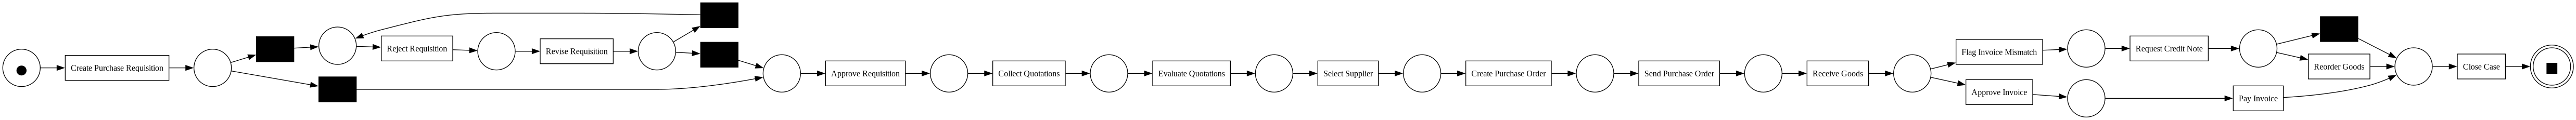

Procurement: saved Petri net -> /home/PSPLab/ProbabilisticSuffixPredictionLab/decision_aware_augmentation_for_PPM/data/Procurement/Petri_net/procurement.pkl


categorical tensors:   0%|          | 0/5 [00:00<?, ?it/s]

concept:name:   0%|          | 0/6500 [00:00<?, ?it/s]

org:resource:   0%|          | 0/6500 [00:00<?, ?it/s]

budget_status:   0%|          | 0/6500 [00:00<?, ?it/s]

...

amount:   0%|          | 0/2000 [00:00<?, ?it/s]

invoice_deviation_pct:   0%|          | 0/2000 [00:00<?, ?it/s]

static categorical:   0%|          | 0/25584 [00:00<?, ?it/s]

Procurement: saved test -> /home/PSPLab/ProbabilisticSuffixPredictionLab/decision_aware_augmentation_for_PPM/data/Procurement/tensor_data/normal/procurement_all_5_test.pkl  (25584 prefixes)


train prefixes: 83492 | test prefixes: 25584 | min_suffix: 5
activity feature 'concept:name': 18 classes
dynamic categorical: ['concept:name', 'org:resource', 'budget_status', 'supplier_type', 'goods_match']
dynamic numerical  : ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day', 'amount', 'invoice_deviation_pct']
cat tensor shape   : (83492, 29) | zero-pad: (83492, 29)


In [3]:
if RUN_BASE:
    data_loading.build_base_dataset(ds)
else:
    print("RUN_BASE=False — inspecting existing tensors.")

try:
    tr = torch.load(dp.normal_tensor(ds, "train"), weights_only=False)
    te = torch.load(dp.normal_tensor(ds, "test"), weights_only=False)
    print(f"train prefixes: {len(tr)} | test prefixes: {len(te)} | min_suffix: {tr.min_suffix_size}")
    acts = tr.all_categories[0][0]
    print(f"activity feature '{acts[0]}': {acts[1]} classes")
    print("dynamic categorical:", [c[0] for c in tr.all_categories[0]])
    print("dynamic numerical  :", [c[0] for c in tr.all_categories[1]])
    print("cat tensor shape   :", tuple(tr.categorical_tensors[0].shape),
          "| zero-pad:", tuple(tr.zero_padding.shape))
except FileNotFoundError as e:
    print("normal tensors not available yet:", e)

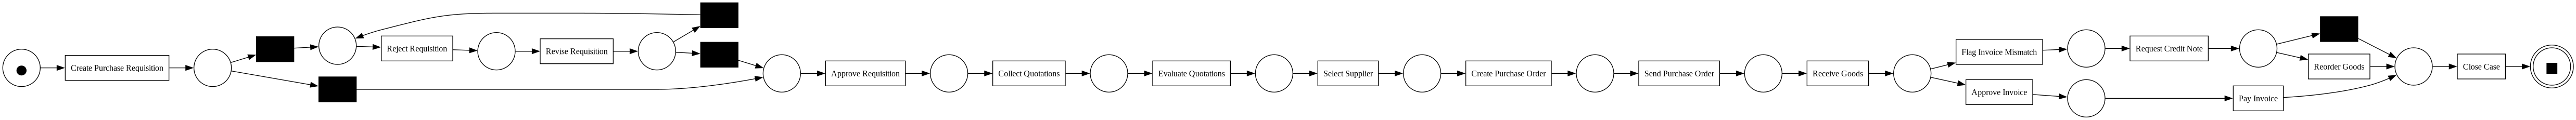

In [4]:
# Discovered Petri net (if present)
from IPython.display import Image, display
if dp.petri_net_png.exists():
    display(Image(filename=str(dp.petri_net_png)))
else:
    print("Petri-net PNG not found:", dp.petri_net_png)

## Stage 2 — Decision mining
We evaluate for each decision point (using the test set): 
1. **support**: how many times the place was visited in the test set (≥ 5 for a place to be considered "informative"),
2. **n_branches**: how many different branches were taken from that place in the test set (≥ 2 for a place to be considered "informative"),
3. **top1_accuracy**: how often the most common branch was taken,
4. **top3_accuracy**: how often the correct branch was among the top 3 most common branches,
5. **informativeness**: A place is informative when its model beats "always predict the majority branch" (lift > 5%) and it genuinely branches (≥ 2 outcomes, support ≥ 5), i.e. the discovered decision model carries real signal about *why* a path was taken.

In [5]:
if RUN_MINING:
    res, guards, result_paths = decision_mining.mine_decision_models(ds)
    print("decision places discovered:", len(guards) if guards is not None else 0)
else:
    print("RUN_MINING=False — inspecting existing decision models.")

INFORMATIVE_LIFT = 0.05    # top1 must beat the majority baseline by this margin
MIN_DECISION_SUPPORT = 5   # min held-out decision instances to judge a place

try:
    diag_df, weighted = decision_mining.decision_diagnostics(ds)
    print("Support-weighted over all places:", weighted)
    need = {"top1_accuracy", "majority_baseline", "n_branches", "support"}
    if not diag_df.empty and need.issubset(diag_df.columns):
        diag_df["lift_over_majority"] = (diag_df["top1_accuracy"] - diag_df["majority_baseline"]).round(4)
        diag_df["informative"] = ((diag_df["n_branches"] >= 2)
                                  & (diag_df["support"] >= MIN_DECISION_SUPPORT)
                                  & (diag_df["lift_over_majority"] > INFORMATIVE_LIFT))
        cols = ["decision_place", "support", "n_branches", "majority_baseline",
                "top1_accuracy", "top3_accuracy", "lift_over_majority", "informative"]
        display(diag_df[cols].sort_values("support", ascending=False).reset_index(drop=True))
        n_inf, n_tot = int(diag_df["informative"].sum()), len(diag_df)
        inf_sup = float(diag_df.loc[diag_df["informative"], "support"].sum())
        tot_sup = float(diag_df["support"].sum()) or 1.0
        print(f"\nInformative places: {n_inf}/{n_tot} "
              f"covering {100*inf_sup/tot_sup:.0f}% of held-out decision instances "
              f"(top1 beats majority by > {INFORMATIVE_LIFT:.0%}).")
    else:
        display(diag_df)
except FileNotFoundError as e:
    print("decision artifacts not available yet:", e)

aligning log, completed variants ::   0%|          | 0/15 [00:00<?, ?it/s]

Procurement: mining over 8000 train+val cases (102776 events); numeric scalers: ['case_elapsed_time', 'amount', 'invoice_deviation_pct']


Procurement: saved decision artifacts -> /home/PSPLab/ProbabilisticSuffixPredictionLab/decision_aware_augmentation_for_PPM/data/Procurement/Petri_net/data_aware_Petri_net
decision places discovered: 4


aligning log, completed variants ::   0%|          | 0/15 [00:00<?, ?it/s]

Support-weighted over all places: {'weighted_top1': 0.8301944572041035, 'weighted_top3': 1.0, 'total_support': 6531}


,decision_place,support,n_branches,majority_baseline,top1_accuracy,top3_accuracy,lift_over_majority,informative
0,p_15,2000.0,2,0.601500,0.897500,1.0,0.2960,True
1,p_3,2000.0,2,0.521500,0.760500,1.0,0.2390,True
2,p_6,1734.0,2,0.601499,0.765283,1.0,0.1638,True
3,p_19,797.0,2,0.854454,0.977415,1.0,0.1230,True



Informative places: 4/4 covering 100% of held-out decision instances (top1 beats majority by > 5%).


## Stage 3 — Decision labeling

In [6]:
if RUN_LABELING:
    data_loading.build_decision_labeled_dataset(ds)
else:
    print("RUN_LABELING=False — inspecting existing decision-labeled tensors.")

# inspect: guard coverage + example z-distributions ---
try:
    dtr = torch.load(dp.decision_tensor(ds, "train"), weights_only=False)
    gt, gm = dtr._guard_targets, dtr._guard_mask
    print(f"guard_targets {tuple(gt.shape)} | guard_mask {tuple(gm.shape)}")
    print(f"labeled positions: {gm.sum().item():.0f} / {gm.numel()} "
          f"({100*gm.float().mean().item():.2f}% of all positions)")
    # first sample with at least one decision label
    dd = dtr.decision_data
    for row in dd:
        labeled = [(p, z) for (p, z) in row if p != "⊥" and z]
        if labeled:
            print("\nexample event decision labels (place -> top-3 z):")
            for place, z in labeled[:3]:
                top = sorted(z.items(), key=lambda kv: -kv[1])[:3]
                print(f"  {place}: {top}")
            break
except FileNotFoundError as e:
    print("decision-labeled tensors not available yet:", e)

aligning log, completed variants ::   0%|          | 0/15 [00:00<?, ?it/s]

Procurement: 8000 alignments for 8000 cases


Procurement train: guard_targets (83492, 29, 18), guard_mask (83492, 29)


Procurement val: guard_targets (19284, 29, 18), guard_mask (19284, 29)


Procurement: saved decision-labeled train -> /home/PSPLab/ProbabilisticSuffixPredictionLab/decision_aware_augmentation_for_PPM/data/Procurement/tensor_data/decision_labeled/procurement_all_5_train.pkl


Procurement: saved decision-labeled val -> /home/PSPLab/ProbabilisticSuffixPredictionLab/decision_aware_augmentation_for_PPM/data/Procurement/tensor_data/decision_labeled/procurement_all_5_val.pkl


guard_targets (83492, 29, 18) | guard_mask (83492, 29)
labeled positions: 248690 / 2421268 (10.27% of all positions)

example event decision labels (place -> top-3 z):
  p_3: [('Approve Requisition', 0.9616796721849856), ('Reject Requisition', 0.03832032781501439)]


## Stage 4 — Training

Train each architecture **clean** and **decision-aware** using the manually-set `TRAIN_PARAMS`.

In [7]:
def _apply_params(cfg, params):
    # Override ModelConfig fields (epochs, learning_rate, lambda_sem, tau, ...) for this run.
    if not params:
        return cfg
    return dataclasses.replace(cfg, model=dataclasses.replace(cfg.model, **params))

histories = {}
if RUN_TRAINING:
    for model in TRAIN_MODELS:
        for variant in TRAIN_VARIANTS:
            cfg = _apply_params(make_experiment(DATASET, model, variant),
                                TRAIN_PARAMS.get(variant, {}))
            mc = cfg.model
            print(f"\n=== training {model}/{variant} "
                  f"(epochs={mc.epochs}, lr={mc.learning_rate}, "
                  f"lambda_sem={mc.lambda_sem}, tau={mc.tau}) ===")
            histories[(model, variant)] = training.train(cfg)
else:
    print("RUN_TRAINING=False — skipping training (using existing checkpoints).")


=== training UED/clean (epochs=100, lr=1e-05, lambda_sem=0.3, tau=0.2) ===


Dynamic data set categories:  ([('concept:name', 18, {'Approve Invoice': 1, 'Approve Requisition': 2, 'Close Case': 3, 'Collect Quotations': 4, 'Create Purchase Order': 5, 'Create Purchase Requisition': 6, 'EOS': 7, 'Evaluate Quotations': 8, 'Flag Invoice Mismatch': 9, 'Pay Invoice': 10, 'Receive Goods': 11, 'Reject Requisition': 12, 'Reorder Goods': 13, 'Request Credit Note': 14, 'Revise Requisition': 15, 'Select Supplier': 16, 'Send Purchase Order': 17}), ('org:resource', 22, {'Alice': 1, 'Bob': 2, 'Buyer_1': 3, 'Buyer_2': 4, 'Buyer_3': 5, 'Carol': 6, 'Clerk_1': 7, 'Clerk_2': 8, 'Clerk_3': 9, 'David': 10, 'EOS': 11, 'Eva': 12, 'Frank': 13, 'Manager_FIN_1': 14, 'Manager_FIN_2': 15, 'Manager_IT_1': 16, 'Manager_IT_2': 17, 'Manager_OPS_1': 18, 'Manager_OPS_2': 19, 'Receiver_A': 20, 'Receiver_B': 21}), ('budget_status', 4, {'EOS': 1, 'approved': 2, 'pending': 3}), ('supplier_type', 6, {'EOS': 1, 'preferred': 2, 'risky': 3, 'standard': 4, nan: 5}), ('goods_match', 5, {'EOS': 1, 'False': 2

Device: cuda
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 0.0
)
Scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x7f6e00cf1e20>
Epochs: 100, mini-batch size: 128, shuffle: True
Regularization: 0.0001
Teacher forcing mode: scheduled
Scheduled sampling ε: 0.0 -> 1.0 (inverse-sigmoid)


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch [1/100], Learning Rate: 1e-05, Teacher forcing ratio: 1.0000, Scheduled sampling epsilon: 0.0000
Training: Avg Attenuated Training Loss (total): 6.0155


...

Epoch [16/20], LR: None, τ: 0.0258, TF: 0.0017, ε: 0.9983, Gen Loss: 3.0361, Disc Loss: 1.2841
Training: Avg Semantic Loss L_sem (raw): 0.0845, weighted λ_sem·L_sem: 0.0254
saving model


Epoch [17/20], LR: None, τ: 0.0204, TF: 0.0010, ε: 0.9990, Gen Loss: 3.1184, Disc Loss: 1.2750
Training: Avg Semantic Loss L_sem (raw): 0.0793, weighted λ_sem·L_sem: 0.0238
saving model


Epoch [18/20], LR: None, τ: 0.0161, TF: 0.0006, ε: 0.9994, Gen Loss: 3.2162, Disc Loss: 1.2638
Training: Avg Semantic Loss L_sem (raw): 0.0778, weighted λ_sem·L_sem: 0.0233
saving model


Epoch [19/20], LR: None, τ: 0.0127, TF: 0.0004, ε: 0.9996, Gen Loss: 3.3039, Disc Loss: 1.2546
Training: Avg Semantic Loss L_sem (raw): 0.0772, weighted λ_sem·L_sem: 0.0232
saving model


Epoch [20/20], LR: None, τ: 0.0100, TF: 0.0002, ε: 0.9998, Gen Loss: 3.3536, Disc Loss: 1.2468
Training: Avg Semantic Loss L_sem (raw): 0.0774, weighted λ_sem·L_sem: 0.0232
saving model
Training complete.
Model saved to path: /home/PSPLab/ProbabilisticSuffixPredictionLab/decision_aware_augmentation_for_PPM/models/Procurement/decision/Procurement_GAN_LSTM_v1_DA.pkl


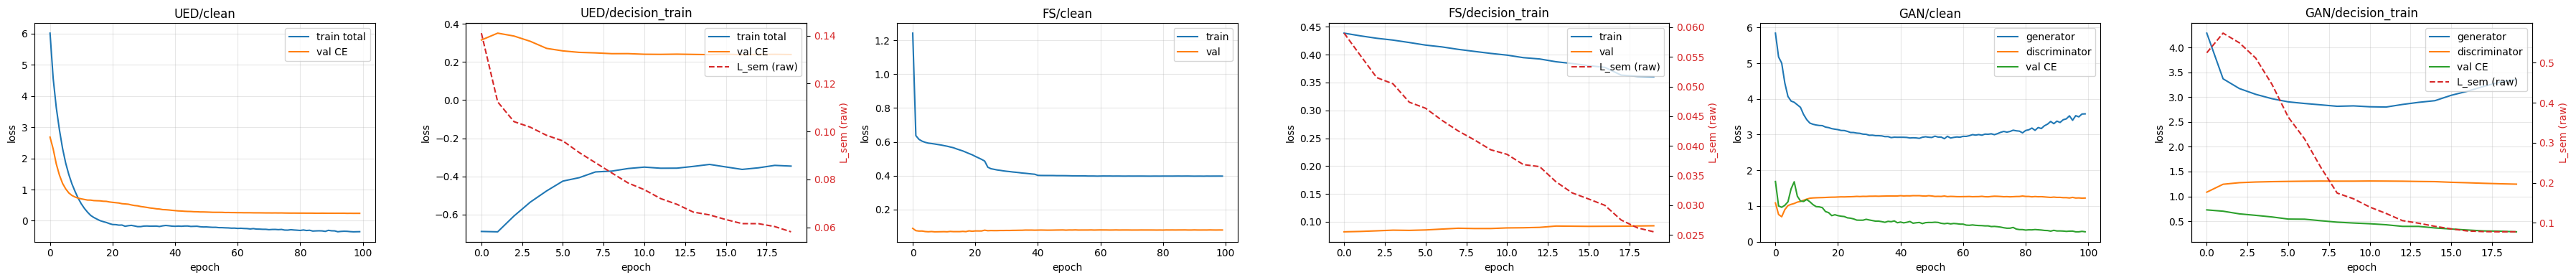

In [8]:
# Loss curves. For decision-aware runs the raw semantic loss L_sem is plotted on a
# twin axis (different scale) for all three architectures (UED, FS, GAN each return
# their per-epoch L_sem).
if histories:
    fig, axes = plt.subplots(1, len(histories), figsize=(6 * len(histories), 4), squeeze=False)
    for ax, ((model, variant), hist) in zip(axes[0], histories.items()):
        sem = None
        if model == "UED":
            train_loss, val_loss, val_att, sem = hist
            ax.plot(train_loss, label="train total")
            ax.plot(val_loss, label="val CE")
        elif model == "GAN":
            gen_loss, disc_loss, val_loss, sem = hist
            ax.plot(gen_loss, label="generator")
            ax.plot(disc_loss, label="discriminator")
            ax.plot(val_loss, label="val CE")
        elif model == "FS":
            train_loss, val_loss, sem = hist
            ax.plot(train_loss, label="train")
            ax.plot(val_loss, label="val")
        ax.set_title(f"{model}/{variant}"); ax.set_xlabel("epoch"); ax.set_ylabel("loss")
        ax.grid(alpha=0.3)
        # Raw (unweighted) semantic loss on a twin axis; only when it actually fired.
        if sem is not None and any(s > 0 for s in sem):
            ax2 = ax.twinx()
            ax2.plot(range(len(sem)), sem, color="tab:red", linestyle="--", label="L_sem (raw)")
            ax2.set_ylabel("L_sem (raw)", color="tab:red")
            ax2.tick_params(axis="y", labelcolor="tab:red")
            l1, lab1 = ax.get_legend_handles_labels()
            l2, lab2 = ax2.get_legend_handles_labels()
            ax.legend(l1 + l2, lab1 + lab2, loc="upper right")
        else:
            ax.legend()
    plt.tight_layout(); plt.show()
else:
    print("No in-session training histories to plot.")

## Stage 5 — Decoding & reasoning

1. **DLS** — average DLS per (model, variant, mode) + DLS-by-prefix-length curves.
2. **Decision-aware decoding vs mining** — does the semantic loss / guided decode
   raise decision conformance, and does that track the Stage-2 informativeness?
3. **Reasoning** — a single average explainability rate.

Dynamic data set categories:  ([('concept:name', 18, {'Approve Invoice': 1, 'Approve Requisition': 2, 'Close Case': 3, 'Collect Quotations': 4, 'Create Purchase Order': 5, 'Create Purchase Requisition': 6, 'EOS': 7, 'Evaluate Quotations': 8, 'Flag Invoice Mismatch': 9, 'Pay Invoice': 10, 'Receive Goods': 11, 'Reject Requisition': 12, 'Reorder Goods': 13, 'Request Credit Note': 14, 'Revise Requisition': 15, 'Select Supplier': 16, 'Send Purchase Order': 17}), ('org:resource', 22, {'Alice': 1, 'Bob': 2, 'Buyer_1': 3, 'Buyer_2': 4, 'Buyer_3': 5, 'Carol': 6, 'Clerk_1': 7, 'Clerk_2': 8, 'Clerk_3': 9, 'David': 10, 'EOS': 11, 'Eva': 12, 'Frank': 13, 'Manager_FIN_1': 14, 'Manager_FIN_2': 15, 'Manager_IT_1': 16, 'Manager_IT_2': 17, 'Manager_OPS_1': 18, 'Manager_OPS_2': 19, 'Receiver_A': 20, 'Receiver_B': 21}), ('budget_status', 4, {'EOS': 1, 'approved': 2, 'pending': 3}), ('supplier_type', 6, {'EOS': 1, 'preferred': 2, 'risky': 3, 'standard': 4, nan: 5}), ('goods_match', 5, {'EOS': 1, 'False': 2

Probabilistic inference chunks:   0%|          | 0/32 [00:00<?, ?it/s]

Dynamic data set categories:  ([('concept:name', 18, {'Approve Invoice': 1, 'Approve Requisition': 2, 'Close Case': 3, 'Collect Quotations': 4, 'Create Purchase Order': 5, 'Create Purchase Requisition': 6, 'EOS': 7, 'Evaluate Quotations': 8, 'Flag Invoice Mismatch': 9, 'Pay Invoice': 10, 'Receive Goods': 11, 'Reject Requisition': 12, 'Reorder Goods': 13, 'Request Credit Note': 14, 'Revise Requisition': 15, 'Select Supplier': 16, 'Send Purchase Order': 17}), ('org:resource', 22, {'Alice': 1, 'Bob': 2, 'Buyer_1': 3, 'Buyer_2': 4, 'Buyer_3': 5, 'Carol': 6, 'Clerk_1': 7, 'Clerk_2': 8, 'Clerk_3': 9, 'David': 10, 'EOS': 11, 'Eva': 12, 'Frank': 13, 'Manager_FIN_1': 14, 'Manager_FIN_2': 15, 'Manager_IT_1': 16, 'Manager_IT_2': 17, 'Manager_OPS_1': 18, 'Manager_OPS_2': 19, 'Receiver_A': 20, 'Receiver_B': 21}), ('budget_status', 4, {'EOS': 1, 'approved': 2, 'pending': 3}), ('supplier_type', 6, {'EOS': 1, 'preferred': 2, 'risky': 3, 'standard': 4, nan: 5}), ('goods_match', 5, {'EOS': 1, 'False': 2

Probabilistic inference chunks:   0%|          | 0/32 [00:00<?, ?it/s]

Dynamic data set categories:  ([('concept:name', 18, {'Approve Invoice': 1, 'Approve Requisition': 2, 'Close Case': 3, 'Collect Quotations': 4, 'Create Purchase Order': 5, 'Create Purchase Requisition': 6, 'EOS': 7, 'Evaluate Quotations': 8, 'Flag Invoice Mismatch': 9, 'Pay Invoice': 10, 'Receive Goods': 11, 'Reject Requisition': 12, 'Reorder Goods': 13, 'Request Credit Note': 14, 'Revise Requisition': 15, 'Select Supplier': 16, 'Send Purchase Order': 17}), ('org:resource', 22, {'Alice': 1, 'Bob': 2, 'Buyer_1': 3, 'Buyer_2': 4, 'Buyer_3': 5, 'Carol': 6, 'Clerk_1': 7, 'Clerk_2': 8, 'Clerk_3': 9, 'David': 10, 'EOS': 11, 'Eva': 12, 'Frank': 13, 'Manager_FIN_1': 14, 'Manager_FIN_2': 15, 'Manager_IT_1': 16, 'Manager_IT_2': 17, 'Manager_OPS_1': 18, 'Manager_OPS_2': 19, 'Receiver_A': 20, 'Receiver_B': 21}), ('budget_status', 4, {'EOS': 1, 'approved': 2, 'pending': 3}), ('supplier_type', 6, {'EOS': 1, 'preferred': 2, 'risky': 3, 'standard': 4, nan: 5}), ('goods_match', 5, {'EOS': 1, 'False': 2

...

beam inference chunks:   0%|          | 0/32 [00:00<?, ?it/s]

beam inference chunks:   0%|          | 0/32 [00:00<?, ?it/s]

guided_beam chunks:   0%|          | 0/32 [00:00<?, ?it/s]

guided_beam chunks:   0%|          | 0/32 [00:00<?, ?it/s]

,dataset,model,variant,mode,average_dls
0,Procurement,FS,clean,mode,0.860283
1,Procurement,FS,decision_decoding,guided_mode,0.885190
2,Procurement,FS,decision_train,mode,0.854125
3,Procurement,FS,decision_train_decode,guided_mode,0.877190
4,Procurement,GAN,clean,beam,0.896133
5,Procurement,GAN,decision_decoding,guided_beam,0.912868
6,Procurement,GAN,decision_train,beam,0.898970
7,Procurement,GAN,decision_train_decode,guided_beam,0.914237
8,Procurement,UED,clean,probabilistic,0.837156
9,Procurement,UED,decision_decoding,guided_probabilistic,0.850828


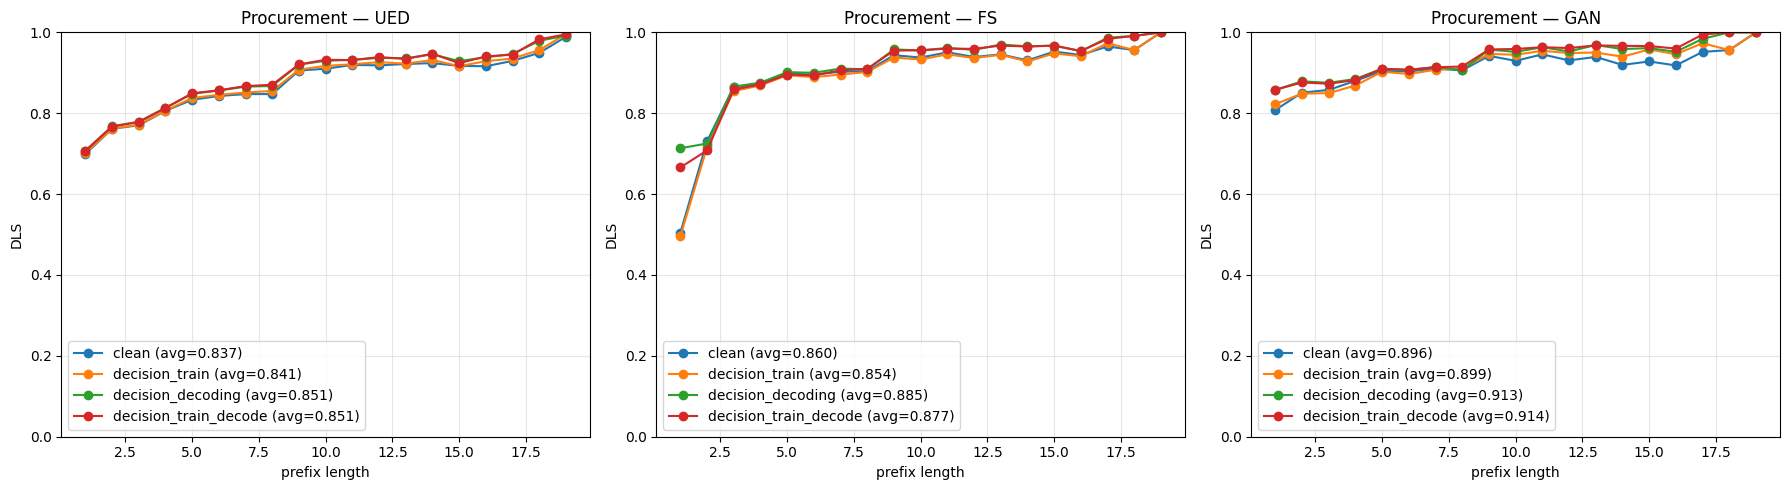

In [9]:
# DLS summary across models/variants (RUN_EVAL=True: decode fresh & overwrite cache; False: read cached).
results, rows = {}, []
for model in EVAL_MODELS:
    for variant in EVAL_VARIANTS:
        cfg = make_experiment(DATASET, model, variant)
        try:
            r = evaluation.evaluate(cfg, force=RUN_EVAL)
            results[(model, variant)] = r
            rows.append(r.summary)
        except Exception as e:
            print(f"skip {model}/{variant}: {type(e).__name__}: {str(e)[:90]}")

summary_df = pd.DataFrame(rows)
if not summary_df.empty:
    dls_summary = summary_df[["dataset", "model", "variant", "mode", "average_dls"]]
    display(dls_summary.sort_values(["model", "variant"]).reset_index(drop=True))
else:
    print("No evaluation results.")

# DLS by prefix length: one plot per model, one curve per mode.
models_present = [m for m in EVAL_MODELS if any((m, v) in results for v in EVAL_VARIANTS)]
if models_present:
    fig, axes = plt.subplots(1, len(models_present), figsize=(6 * len(models_present), 5), squeeze=False)
    for ax, model in zip(axes[0], models_present):
        for variant in EVAL_VARIANTS:
            r = results.get((model, variant))
            if r is None:
                continue
            pp = r.per_prefix
            ax.plot(pp["prefix_len"], pp["dls"], marker="o", label=f"{variant} (avg={r.avg:.3f})")
        ax.set_title(f"{DATASET} — {model}"); ax.set_xlabel("prefix length")
        ax.set_ylabel("DLS"); ax.set_ylim(0, 1); ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()
else:
    print("No evaluation results to plot.")

In [10]:
# Decision-aware decoding vs decision mining.
# Per model: DLS and decision_conformance (in-tau-support rate of decoded decision
# steps) for each variant, as Delta vs the clean baseline. Compare against the
# Stage-2 mining informativeness: guided decoding should raise conformance most
# where the mined decision models are informative.
EFFECT_VARIANTS = ["clean", "decision_train", "decision_decoding", "decision_train_decode"]

def _conformance_for(model, variant):
    # In-tau-support rate of this variant's decoded decision steps.
    if Variant(variant).decode == "guided":
        r = results.get((model, variant))
        cr = r.summary.get("conflict_rate") if r is not None else None
        return (1.0 - cr) if cr is not None else None
    try:
        c = evaluation.evaluate_conformance(make_experiment(DATASET, model, variant), force=RUN_EVAL)
        return c["decision_conformance"]
    except Exception as e:
        print(f"conformance skip {model}/{variant}: {type(e).__name__}: {str(e)[:80]}")
        return None

effect_rows = []
for model in EVAL_MODELS:
    base = results.get((model, "clean"))
    dls_base = base.avg if base is not None else None
    conf_base = _conformance_for(model, "clean")
    for variant in EFFECT_VARIANTS:
        r = results.get((model, variant))
        dls = r.avg if r is not None else None
        conf = _conformance_for(model, variant)
        effect_rows.append({
            "model": model, "variant": variant,
            "DLS": round(dls, 4) if dls is not None else None,
            "decision_conformance": round(conf, 4) if conf is not None else None,
            "dDLS_vs_clean": round(dls - dls_base, 4) if (dls is not None and dls_base is not None) else None,
            "dconf_vs_clean": round(conf - conf_base, 4) if (conf is not None and conf_base is not None) else None,
        })

effect_df = pd.DataFrame(effect_rows)
if not effect_df.empty:
    display(effect_df.sort_values(["model", "variant"]).reset_index(drop=True))
    try:
        _, w = decision_mining.decision_diagnostics(ds)
        print(f"Mining (held-out): weighted top1={w.get('weighted_top1')}, "
              f"weighted top3={w.get('weighted_top3')}.")
    except Exception:
        pass
    print("Target: dconf_vs_clean > 0 with dDLS_vs_clean ~ 0 — strongest where mining is informative.")

Dynamic data set categories:  ([('concept:name', 18, {'Approve Invoice': 1, 'Approve Requisition': 2, 'Close Case': 3, 'Collect Quotations': 4, 'Create Purchase Order': 5, 'Create Purchase Requisition': 6, 'EOS': 7, 'Evaluate Quotations': 8, 'Flag Invoice Mismatch': 9, 'Pay Invoice': 10, 'Receive Goods': 11, 'Reject Requisition': 12, 'Reorder Goods': 13, 'Request Credit Note': 14, 'Revise Requisition': 15, 'Select Supplier': 16, 'Send Purchase Order': 17}), ('org:resource', 22, {'Alice': 1, 'Bob': 2, 'Buyer_1': 3, 'Buyer_2': 4, 'Buyer_3': 5, 'Carol': 6, 'Clerk_1': 7, 'Clerk_2': 8, 'Clerk_3': 9, 'David': 10, 'EOS': 11, 'Eva': 12, 'Frank': 13, 'Manager_FIN_1': 14, 'Manager_FIN_2': 15, 'Manager_IT_1': 16, 'Manager_IT_2': 17, 'Manager_OPS_1': 18, 'Manager_OPS_2': 19, 'Receiver_A': 20, 'Receiver_B': 21}), ('budget_status', 4, {'EOS': 1, 'approved': 2, 'pending': 3}), ('supplier_type', 6, {'EOS': 1, 'preferred': 2, 'risky': 3, 'standard': 4, nan: 5}), ('goods_match', 5, {'EOS': 1, 'False': 2

conformance (mcsa) chunks:   0%|          | 0/32 [00:00<?, ?it/s]

Dynamic data set categories:  ([('concept:name', 18, {'Approve Invoice': 1, 'Approve Requisition': 2, 'Close Case': 3, 'Collect Quotations': 4, 'Create Purchase Order': 5, 'Create Purchase Requisition': 6, 'EOS': 7, 'Evaluate Quotations': 8, 'Flag Invoice Mismatch': 9, 'Pay Invoice': 10, 'Receive Goods': 11, 'Reject Requisition': 12, 'Reorder Goods': 13, 'Request Credit Note': 14, 'Revise Requisition': 15, 'Select Supplier': 16, 'Send Purchase Order': 17}), ('org:resource', 22, {'Alice': 1, 'Bob': 2, 'Buyer_1': 3, 'Buyer_2': 4, 'Buyer_3': 5, 'Carol': 6, 'Clerk_1': 7, 'Clerk_2': 8, 'Clerk_3': 9, 'David': 10, 'EOS': 11, 'Eva': 12, 'Frank': 13, 'Manager_FIN_1': 14, 'Manager_FIN_2': 15, 'Manager_IT_1': 16, 'Manager_IT_2': 17, 'Manager_OPS_1': 18, 'Manager_OPS_2': 19, 'Receiver_A': 20, 'Receiver_B': 21}), ('budget_status', 4, {'EOS': 1, 'approved': 2, 'pending': 3}), ('supplier_type', 6, {'EOS': 1, 'preferred': 2, 'risky': 3, 'standard': 4, nan: 5}), ('goods_match', 5, {'EOS': 1, 'False': 2

conformance (mcsa) chunks:   0%|          | 0/32 [00:00<?, ?it/s]

Dynamic data set categories:  ([('concept:name', 18, {'Approve Invoice': 1, 'Approve Requisition': 2, 'Close Case': 3, 'Collect Quotations': 4, 'Create Purchase Order': 5, 'Create Purchase Requisition': 6, 'EOS': 7, 'Evaluate Quotations': 8, 'Flag Invoice Mismatch': 9, 'Pay Invoice': 10, 'Receive Goods': 11, 'Reject Requisition': 12, 'Reorder Goods': 13, 'Request Credit Note': 14, 'Revise Requisition': 15, 'Select Supplier': 16, 'Send Purchase Order': 17}), ('org:resource', 22, {'Alice': 1, 'Bob': 2, 'Buyer_1': 3, 'Buyer_2': 4, 'Buyer_3': 5, 'Carol': 6, 'Clerk_1': 7, 'Clerk_2': 8, 'Clerk_3': 9, 'David': 10, 'EOS': 11, 'Eva': 12, 'Frank': 13, 'Manager_FIN_1': 14, 'Manager_FIN_2': 15, 'Manager_IT_1': 16, 'Manager_IT_2': 17, 'Manager_OPS_1': 18, 'Manager_OPS_2': 19, 'Receiver_A': 20, 'Receiver_B': 21}), ('budget_status', 4, {'EOS': 1, 'approved': 2, 'pending': 3}), ('supplier_type', 6, {'EOS': 1, 'preferred': 2, 'risky': 3, 'standard': 4, nan: 5}), ('goods_match', 5, {'EOS': 1, 'False': 2

...

conformance (beam) chunks:   0%|          | 0/32 [00:00<?, ?it/s]

conformance (beam) chunks:   0%|          | 0/32 [00:00<?, ?it/s]

,model,variant,DLS,decision_conformance,dDLS_vs_clean,dconf_vs_clean
0,FS,clean,0.8603,0.9046,0.0000,0.0000
1,FS,decision_decoding,0.8852,0.9925,0.0249,0.0879
2,FS,decision_train,0.8541,0.8935,-0.0062,-0.0111
3,FS,decision_train_decode,0.8772,0.9825,0.0169,0.0778
4,GAN,clean,0.8961,0.7593,0.0000,0.0000
5,GAN,decision_decoding,0.9129,0.9722,0.0167,0.2130
6,GAN,decision_train,0.8990,0.7712,0.0028,0.0119
7,GAN,decision_train_decode,0.9142,0.9835,0.0181,0.2242
8,UED,clean,0.8372,0.8100,0.0000,-0.0003
9,UED,decision_decoding,0.8508,0.9687,0.0137,0.1584


aligning log, completed variants ::   0%|          | 0/15 [00:00<?, ?it/s]

Mining (held-out): weighted top1=0.8301944572041035, weighted top3=1.0.
Target: dconf_vs_clean > 0 with dDLS_vs_clean ~ 0 — strongest where mining is informative.


### Reasoning — average explainability rate

For each decision-labeled event decode step whose chosen branch has mined decision rules, we check whether the predicted data state satisfies a rule. 

The single reported metric is the **average explainability rate**:
`explainability_rate = explained_steps / explainable_decision_steps`

where a step is *explainable* when its chosen branch has at least one decision rule
rule (and the decode is non-conflicting), and *explained* when a rule actually
matches the predicted values. Branches with **no** rule are excluded from the
denominator; a branch with a rule that does not match counts in the denominator
only. (This is the `rule_explained_rate` aggregated in
`evaluation._aggregate_reasonings`.)

In [11]:
# Average explainability rate over the guided variants.
GUIDED_VARIANTS = ("decision_decoding", "decision_train_decode")

rows = []
for (model, variant), r in results.items():
    if variant in GUIDED_VARIANTS and r.summary.get("rule_explained_rate") is not None:
        rows.append({"model": model, "variant": variant,
                     "decision_steps": r.summary.get("decision_steps"),
                     "explainable_steps": r.summary.get("explainable_decision_steps"),
                     "explainability_rate": round(r.summary.get("rule_explained_rate"), 4)})

rate_df = pd.DataFrame(rows)
if not rate_df.empty:
    display(rate_df.sort_values(["model", "variant"]).reset_index(drop=True))
    print(f"Average explainability rate: {rate_df['explainability_rate'].mean():.3f}")
else:
    print("No guided reasoning results available.")

,model,variant,decision_steps,explainable_steps,explainability_rate
0,FS,decision_decoding,33866,28045,0.3567
1,FS,decision_train_decode,34709,27945,0.3834
2,GAN,decision_decoding,112226,86797,0.2713
3,GAN,decision_train_decode,104089,86778,0.2595
4,UED,decision_decoding,4145036,2971169,0.4562
5,UED,decision_train_decode,4153875,2963784,0.4813


Average explainability rate: 0.368


**Example suffix prediction output** 

In [1]:
# One worked reasoning example, for transparency.
#
# Self-contained: re-run this cell on its own (e.g. after a kernel restart) to
# draw a *different* random example, as long as the pipeline has been executed
# once so the eval caches exist on disk. It reuses the in-memory `results` when
# present, otherwise reloads the guided variants from the stored eval cache
# (force=False = read cache only, no re-decoding / no re-running earlier stages).
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("TORCH_NUM_THREADS", "1")
import sys, random, pickle
sys.path.insert(0, "..")
from suffix_pred.experiments import DATASETS, MODELS, make_experiment, resolve_dataset_paths
import suffix_pred.experiments.evaluation as evaluation
from suffix_pred.decision_rule_guided_reasoning_inference import (
    format_value_for_display, render_rule_for_display)

DATASET = globals().get("DATASET", "Procurement")
ds = globals().get("ds") or DATASETS[DATASET]
dp = globals().get("dp") or resolve_dataset_paths(ds)
GUIDED_VARIANTS = ("decision_decoding", "decision_train_decode")

# Reuse this session's results if they already hold guided variants; otherwise
# load the guided variants from the eval cache so the cell stands alone.
results = globals().get("results") or {}
if not any(v in GUIDED_VARIANTS for (_, v) in results):
    results = {}
    for model in MODELS:
        for variant in GUIDED_VARIANTS:
            try:
                results[(model, variant)] = evaluation.evaluate(
                    make_experiment(DATASET, model, variant), force=False)
            except Exception as e:
                print(f"skip {model}/{variant}: {type(e).__name__}: {str(e)[:90]}")

# numeric scalers -> decode z-scaled values back to original units.
numeric_scalers = None
if dp.numeric_scalers.exists():
    with open(dp.numeric_scalers, "rb") as f:
        numeric_scalers = pickle.load(f)


def _print_step(step):
    nxt = step["next_event"]
    top, top_p = step.get("decision_top_event"), step.get("decision_top_prob")
    mp = step.get("model_prob")
    mp_str = f"{mp:.1%}" if mp is not None else "?"
    if top is not None and top != nxt:
        tp = f"{top_p:.1%}" if top_p is not None else "?"
        print(f"  step {step['step']} @ {step['place']}: {step['input_event']} -> {nxt}  "
              f"[model {mp_str}; decision top {top} p={tp}; conflict={step.get('conflict')}]")
    else:
        tp = f"; decision top p={top_p:.1%}" if top_p is not None else ""
        print(f"  step {step['step']} @ {step['place']}: {step['input_event']} -> {nxt}  "
              f"[model {mp_str}{tp}]")
    rule = step.get("matched_rule")
    if rule and rule.get("rule"):
        print(f"      rule: {render_rule_for_display(rule['rule'], numeric_scalers)} "
              f"(p={rule.get('prob_model', 0):.1%}, support={rule.get('support', 0)})")
    for chk in step.get("attribute_checks", []):
        attr = chk.get("attr", "")
        val = format_value_for_display(attr, chk.get("value"), numeric_scalers)
        print(f"      ({attr}, {val}, in_set={bool(chk.get('in_rule_set', False))})")


# pick a random guided case whose decode has at least one decision step.
case_pool = [(m, v, orow, rrow)
             for (m, v), r in results.items() if v in GUIDED_VARIANTS and r.reasoning
             for orow, rrow in zip(r.outputs, r.reasoning)
             if rrow.get("reasoning", {}).get("decision_steps", 0) > 0]

if case_pool:
    model, variant, orow, rrow = random.choice(case_pool)
    sample_idx, chosen = 0, rrow.get("reasoning", {})
    for j, rs in enumerate(rrow.get("reasonings", [])):
        if rs.get("trace"):
            sample_idx, chosen = j, rs
            break
    decoded = orow["decoded_suffixes"]
    decoded = decoded[sample_idx] if sample_idx < len(decoded) else decoded[0]

    print(f"\nExample — {model}/{variant} | case {orow['case_id']} | prefix_len {orow['prefix_len']}")
    print(f"Prefix:        {orow['prefix']}")
    print(f"Target suffix: {orow['target_suffix']}")
    print(f"Predicted:     {decoded}")
    print(f"decision_steps={chosen.get('decision_steps', 0)} "
          f"conflicts={chosen.get('conflicts', 0)} explained={chosen.get('explained_steps', 0)}")
    for step in chosen.get("trace", []):
        _print_step(step)
else:
    print("No guided reasoning traces available.")


Example — FS/decision_decoding | case C02220 | prefix_len 4
Prefix:        ['Create Purchase Requisition', 'Reject Requisition', 'Revise Requisition', 'Reject Requisition']
Target suffix: ['Revise Requisition', 'Approve Requisition', 'Collect Quotations', 'Evaluate Quotations', 'Select Supplier', 'Create Purchase Order', 'Send Purchase Order', 'Receive Goods', 'Approve Invoice', 'Pay Invoice', 'Close Case']
Predicted:     ['Revise Requisition', 'Approve Requisition', 'Collect Quotations', 'Evaluate Quotations', 'Select Supplier', 'Create Purchase Order', 'Send Purchase Order', 'Receive Goods', 'Approve Invoice', 'Pay Invoice', 'Close Case']
decision_steps=2 conflicts=0 explained=1
  step 1 @ p_6: Revise Requisition -> Approve Requisition  [model 100.0%; decision top p=94.3%]
      rule: (budget_status not in {pending}) AND (department in {Finance}) AND (amount > 6,035.46) AND (amount <= 8,962.72) (p=75.6%, support=549)
      (amount, 6,064.76, in_set=True)
      (department, Finance, 